## Import all Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import cv2
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import models, transforms

import urllib.request

## Use the ImageNet transformation

In [2]:
def preprocess_image(img_path):

    """Load and preprocess images for PyTorch models."""

    img = Image.open(img_path).convert("RGB")

    #Transforms used by imagenet models
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    return transform(img).unsqueeze(0)

In [3]:
# Load the pre-trained model (e.g., VGG16)
model = models.vgg16(pretrained=True)

# Set the model to gpu
device = torch.device('mps' if torch.backends.mps.is_built()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
model.to(device)

# Set the model to evaluation mode
model.eval()

m:\Ashesi\Sem 2\Computer Vision\Grad-CAM Clone\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
m:\Ashesi\Sem 2\Computer Vision\Grad-CAM Clone\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

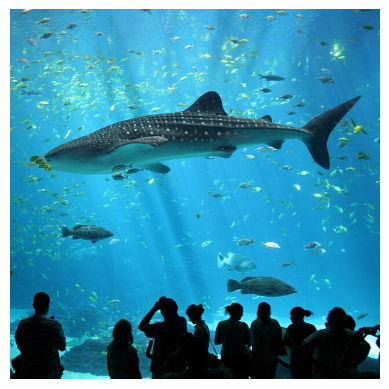

In [4]:
# Load a sample image from the web
img_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/Male_whale_shark_at_Georgia_Aquarium.jpg/960px-Male_whale_shark_at_Georgia_Aquarium.jpg"

# Create a request with a User-Agent header to avoid 403 Forbidden error
req = urllib.request.Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as url_response:
    with open("sample_image.jpg", "wb") as f:
        f.write(url_response.read())

img_path = "sample_image.jpg"
img = Image.open(img_path).convert("RGB")
img = img.crop((320, 0, 960, 640))  # Crop to 640x640

plt.imshow(img)
plt.axis("off")

In [5]:
# Guided Backpropagation implementation (tensor-level hooks to avoid view/inplace issues)
def guided_backprop(model, input_tensor, class_index):
    model.eval()
    # Ensure input requires grad
    inp = input_tensor.clone().detach().requires_grad_(True)

    module_hooks = []
    tensor_hooks = []

    def forward_hook(module, inp_t, out_t):
        # Register a hook on the tensor output to clamp gradients during backward
        if isinstance(out_t, torch.Tensor):
            def tensor_grad_hook(grad):
                g = grad.clone()  # clone to avoid inplace/view modification
                return torch.clamp(g, min=0.0)
            tensor_hooks.append(out_t.register_hook(tensor_grad_hook))

    # Attach forward hooks to ReLU modules so their outputs get tensor hooks
    for module in model.modules():
        if isinstance(module, torch.nn.ReLU):
            module_hooks.append(module.register_forward_hook(forward_hook))

    # Forward and backward pass
    model.zero_grad()
    out = model(inp)
    loss = out[0, class_index]
    loss.backward()

    # extract gradient wrt input and cleanup hooks
    grad = inp.grad.detach().cpu().numpy()[0]  # C,H,W
    for h in module_hooks: h.remove()
    for th in tensor_hooks: th.remove()

    # convert to HxW grayscale by summing absolute across channels
    gb = np.transpose(grad, (1, 2, 0))
    gb = np.sum(np.abs(gb), axis=2)
    gb = gb - gb.min()
    if gb.max() != 0:
        gb = gb / gb.max()
    return gb

In [6]:
# ensure CPU device and move model/input there
device = torch.device('cpu')
model.to(device)

# recreate input and predictions
img_tensor = preprocess_image(img_path).to(device)
predictions = model(img_tensor)

# top-3 ids used by visualization
probs = torch.nn.functional.softmax(predictions[0], dim=0)
top_prob, top_catid = torch.topk(probs, 3)

In [7]:
def generate_gradcam(model, input_tensor, class_index, target_layer_idx=28):
    """Compute Grad-CAM heatmap for `class_index` using `target_layer_idx`."""
    activations = []
    gradients = []
    tensor_hooks = []

    def save_activations(module, inp, out):
        # out shape: (batch, C, H, W) - save activations (CPU) for post-processing
        activations.append(out.detach().cpu())
        # register a tensor hook on the activation tensor to capture its gradient during backward
        def tensor_grad_hook(grad):
            if grad is None:
                return None
            # clone to avoid view+inplace autograd errors and store on CPU
            gradients.append(grad.clone().detach().cpu())
            return None
        tensor_hooks.append(out.register_hook(tensor_grad_hook))

    # register forward hook on the target module only (we'll capture gradients via tensor hooks)
    fhook = model.features[target_layer_idx].register_forward_hook(save_activations)

    # forward/backward pass
    model.zero_grad()
    output = model(input_tensor)
    target = output[0, class_index]
    target.backward()

    # remove hooks
    fhook.remove()
    for th in tensor_hooks: th.remove()

    if len(activations) == 0 or len(gradients) == 0:
        raise RuntimeError('Hooks did not capture activations/gradients. Ensure the target layer index is correct and the forward pass ran.')

    acts = activations[0].squeeze(0).numpy()  # (C, H, W)
    grads = gradients[0].squeeze(0).numpy()  # (C, H, W)

    # channel-wise weights via GAP over spatial dims
    weights = np.mean(grads, axis=(1, 2))  # (C,)

    # weighted combination of activations
    cam = np.sum(acts * weights[:, np.newaxis, np.newaxis], axis=0)

    # ReLU
    cam = np.maximum(cam, 0)

    # Normalize to [0,1]
    cam = cam - np.min(cam)
    if np.max(cam) != 0:
        cam = cam / np.max(cam)

    # Upsample to input size
    h = input_tensor.size(2)
    w = input_tensor.size(3)
    cam_upsampled = cv2.resize(cam, (w, h), interpolation=cv2.INTER_LINEAR)

    return cam_upsampled

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

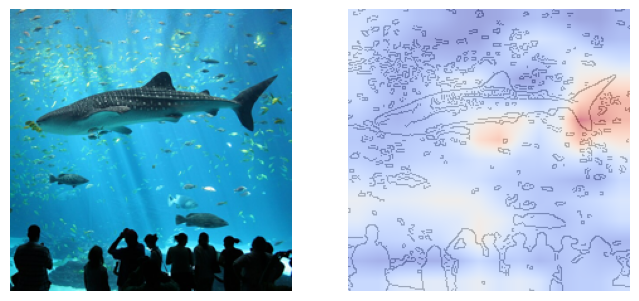

In [8]:
# Step 5: visualise the heatmap for the top prediction
fig, ax = plt.subplots(1, 2, figsize=(8, 8))

# Ensure resized image
resized_img = img.resize((224, 224))
ax[0].imshow(resized_img)
ax[0].axis("off")

# Edge map for the input image
edge_img = cv2.Canny(np.array(resized_img), 100, 200)
ax[1].imshow(255-edge_img, alpha=0.5, cmap='gray')

# Compute heatmap using the reusable function (top predicted class)
top_cls = top_catid[0].item()
upsampled_heatmap = generate_gradcam(model, img_tensor, top_cls, target_layer_idx=28)

# Overlay the heatmap
ax[1].imshow(upsampled_heatmap, alpha=0.5, cmap='coolwarm')
ax[1].axis("off")

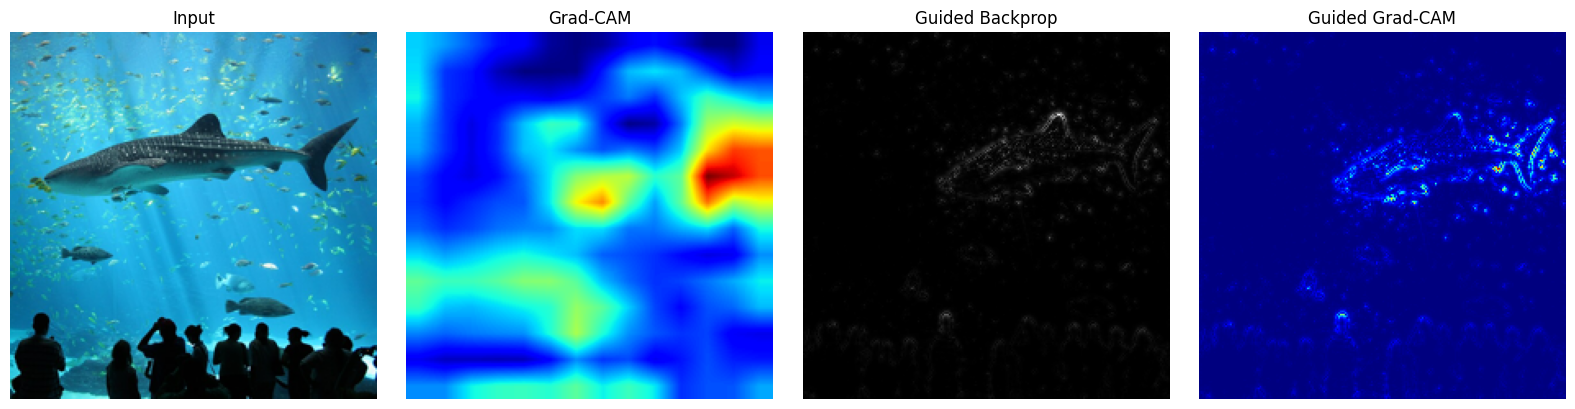

In [9]:
# Visualise Guided Backprop + Guided Grad-CAM for the top prediction
cls = top_catid[0].item()
cam = generate_gradcam(model, img_tensor, cls, target_layer_idx=28)
gb = guided_backprop(model, img_tensor, cls)
guided_gc = gb * cam

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(resized_img)
axes[0].axis('off')
axes[0].set_title('Input')
axes[1].imshow(cam, cmap='jet')
axes[1].axis('off')
axes[1].set_title('Grad-CAM')
axes[2].imshow(gb, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Guided Backprop')
axes[3].imshow(guided_gc, cmap='jet')
axes[3].axis('off')
axes[3].set_title('Guided Grad-CAM')
plt.tight_layout()

In [16]:
# 10-image smoke test using PASCAL VOC and eval_utils
from eval_utils import make_pascal_dataloader, batch_generate_gradcam
from torch.utils.data import Subset, DataLoader
import torch

# Adjust `root` to where you have VOCdevkit (or set download=True in make_pascal_dataloader)
root = 'VOCdevkit'
# Set download=True so datasets are fetched if missing; torchvision will skip if already present
loader = make_pascal_dataloader(root=root, year='2007', image_set='val', batch_size=1, num_workers=0, download=True)
ds = loader.dataset
subset = Subset(ds, range(min(10, len(ds))))
# Use a collate_fn that returns the single sample unchanged to avoid collating PIL images
sub_loader = DataLoader(subset, batch_size=1, shuffle=False, num_workers=0, collate_fn=lambda batch: batch[0])
 
rows = batch_generate_gradcam(model, sub_loader, device=device, gradcam_fn=generate_gradcam, out_dir='outputs/pascal_smoke', topk=1)
print('Smoke test completed — saved heatmaps:', len(rows))

Grad-CAM batches: 100%|██████████| 10/10 [00:34<00:00,  3.45s/it]

Smoke test completed — saved heatmaps: 10


In [17]:
# Evaluation: pointing game and deletion sensitivity (first 3 images)
import importlib
import eval_utils
importlib.reload(eval_utils)
from eval_utils import pointing_game_eval, deletion_sensitivity
import numpy as np

# Pointing game on smoke results
hit_rate, hits = pointing_game_eval(rows)
print(f'Pointing game hit rate: {hit_rate:.3f} ({sum(hits)}/{len(hits)})')

# Build index map for subset samples
id_to_idx = {subset[i]['image_id']: i for i in range(len(subset))}

# Run deletion sensitivity on first 3 results
for r in rows[:3]:
    img_id = r['image_id']
    idx = id_to_idx.get(img_id, None)
    if idx is None:
        print('Sample not found in subset for', img_id)
        continue
    sample = subset[idx]
    img_t = sample['img_tensor'].to(device)
    cls = r['class_index']
    # recompute heatmap for deletion test
    cam = generate_gradcam(model, img_t, cls, target_layer_idx=28)
    res = deletion_sensitivity(model, img_t, cam, cls, device=device, steps=10, baseline='mean')
    print(f'{img_id} deletion AUC: {res["auc"]:.4f}')


Pointing game hit rate: 0.600 (6/10)
000005.jpg deletion AUC: 0.0379
000007.jpg deletion AUC: 0.1071
000009.jpg deletion AUC: 0.0173
